# **MÓDULO 33 - Projeto Final de Modelos Avançados**

**Objetivo do Projeto:**

O objetivo deste projeto é aplicar os conceitos aprendidos nos módulos de conceitos avançados de modelagem para realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means. Ao final do projeto, você terá a oportunidade de consolidar seus conhecimentos em exploração de dados, pré-processamento, implementação e avaliação de modelos.

**Exploração de Dados:**

Inicie explorando o dataset fornecido, buscando entender as principais características das variáveis e a distribuição dos dados.

Realize análises descritivas, identifique padrões, e verifique a presença de valores ausentes ou inconsistências que precisem ser tratadas.

**Tratamento de Dados:**

Realize os tratamentos necessários como limpeza de dados, normalização ou padronização das variáveis, e, se necessário, a criação de variáveis derivadas.

Documente cada etapa do tratamento, explicando o motivo das escolhas feitas e como elas impactam no modelo.

**Implementação do Algoritmo K-Means:**

Aplique o algoritmo K-Means no dataset tratado. Defina o número de clusters (k).
Execute o algoritmo, ajuste os parâmetros conforme necessário, e documente o processo.

**Avaliação e Interpretação dos Resultados:**

Avalie a qualidade dos clusters gerados utilizando métricas adequadas.

Interprete os resultados, descrevendo as características de cada cluster e como eles podem ser utilizados para a segmentação de clientes.

Sugira aplicações práticas para os clusters identificados, como estratégias de marketing direcionadas ou personalização de ofertas.

**O dataset a ser utilizado neste projeto contém informações de 200 clientes, com os seguintes atributos:**

CustomerID: Identificador único atribuído a cada cliente.

Gender: Gênero do cliente.

Age: Idade do cliente.

Annual Income (k$): Renda anual do cliente em milhares de dólares.

Spending Score (1-100): Pontuação atribuída pelo shopping com base no
comportamento e padrão de gastos do cliente.

Notem que neste projeto vocês terão autonomia para criar os passos e justificar, sempre, os passos escolhidos.

In [5]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Bibliotecas para pré-processamento e divisão de dados
from sklearn.preprocessing import StandardScaler

# Bibliotecas para os modelos de machine learning
from sklearn.cluster import KMeans

In [6]:
base = pd.read_csv("Mall_Customers.csv", delimiter=',')

In [7]:
#Visualizar dados
base

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [8]:
#Verificar dados nulos e tipos de dados
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


O dataframe não possui dados nulos, portanto não é ncessário um tratamento para tal.

In [9]:
#Verificar erros de digitação na coluna Gender
base['Gender'].unique()

array(['Male', 'Female'], dtype=object)

O dataframe não possui entradas diferentes na coluna *Gender*, a´penas Male e Female, portanto nenhum tratamento é necessário, poderia-se simplificar as entradas como 'm' e 'f', porem foi decidido manter os dados como no original.
Como K-means não lida com dados categóricos, e transformar esses dados com One-Hot Encoding deve gerar poucos ganhos, está coluna não será utilizada

In [10]:
#Verificar outliers e range de dados
base.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Análise inicial:  
- CustomerID deve ser ignorado pois não é um parametro importante para a analise, sendo apenas um identificador;
- Age está dentro do esperado, dentro de um range aceitavel (18 a 70 anos), com mediana e média proximas e sem outliers;
- Annual Income está dentro de um range aceitavel, com mediana e média proximas e sem outliers aparentes;
- Spending Score, desntro do esperado não contendo valores fora da escala (1-100) adotada.

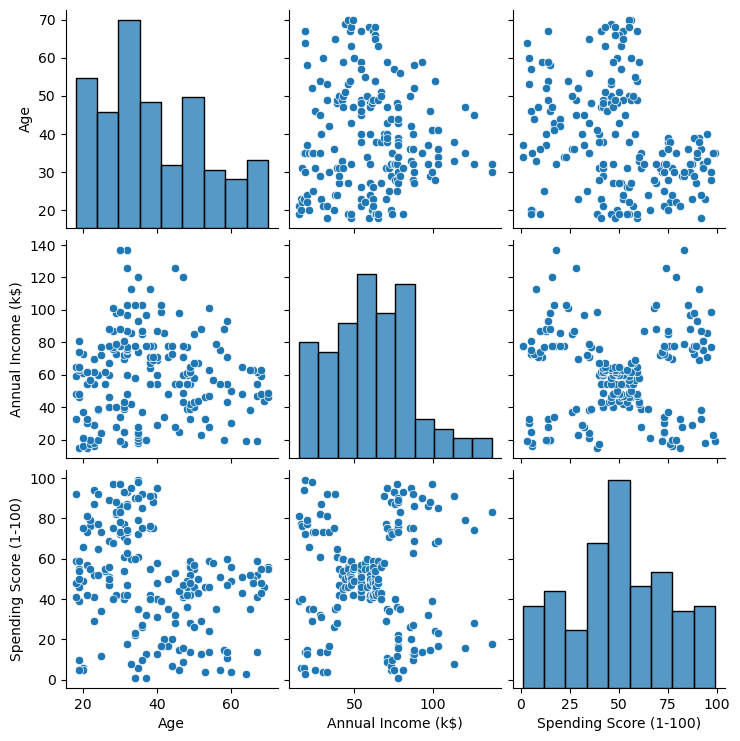

In [11]:
# Retirar colunas irrelevantes
base2 = base.drop(columns=['CustomerID','Gender'])

# Pairplot para verificação visual de numero de klusters
sns.pairplot(base2)

- Annual Income vs Spending Score aparecem agrupamentos bem definidos, sugerindo que há diferentes perfis de clientes, em primeira analise aparecem 5 clusters distintos (Baixa renda x alto score, baixa renda x baixo score, média renda x médio score, alta renda x baixo score, alta renda x alto score);
- Age vs Spending Score apresenta alta dispersão, sem clisters evidentes, porem com alguns padrões de concentração;
- Age vs Annual Income, mostra uma distribuição mais contínua, sem cluster claros.


A partir dos dados apresentados, iremos realizar o primeiro K-means com **5 clusters**.

In [12]:
base_std = base2.copy()

colunas_std = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Inicializar o StandardScaler
scaler = StandardScaler()

# Ajustar e transformar os dados selecionados
base_std[colunas_std] = scaler.fit_transform(base2[colunas_std])

In [13]:
base_std

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
...,...,...,...
195,-0.276302,2.268791,1.118061
196,0.441365,2.497807,-0.861839
197,-0.491602,2.497807,0.923953
198,-0.491602,2.917671,-1.250054


In [14]:
#Aplicar K-means
kmeans_mall = KMeans (n_clusters=5, n_init=10, random_state=42)
kmeans_mall.fit(base_std)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [15]:
centroides = kmeans_mall.cluster_centers_
centroides

array([[ 0.5310735 , -1.2905084 , -1.23646671],
       [-0.98067852, -0.74305983,  0.46744035],
       [-0.42880597,  0.97484722,  1.21608539],
       [ 0.07333084,  0.97494509, -1.19729675],
       [ 1.20484056, -0.23577338, -0.05236781]])

In [16]:
centroides_std = kmeans_mall.cluster_centers_

# Inverter a padronização para obter os centroides originais
centroides_ori = scaler.inverse_transform(centroides_std)
centroides_ori

array([[46.25      , 26.75      , 18.35      ],
       [25.18518519, 41.09259259, 62.24074074],
       [32.875     , 86.1       , 81.525     ],
       [39.87179487, 86.1025641 , 19.35897436],
       [55.63829787, 54.38297872, 48.85106383]])

In [17]:
labels = kmeans_mall.labels_
labels

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1,
       0, 1, 4, 1, 1, 1, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 4, 1,
       4, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1,
       1, 4, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 4, 4, 1, 4, 1, 4, 4, 4, 4,
       4, 1, 3, 1, 1, 1, 4, 4, 4, 4, 1, 3, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 4, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

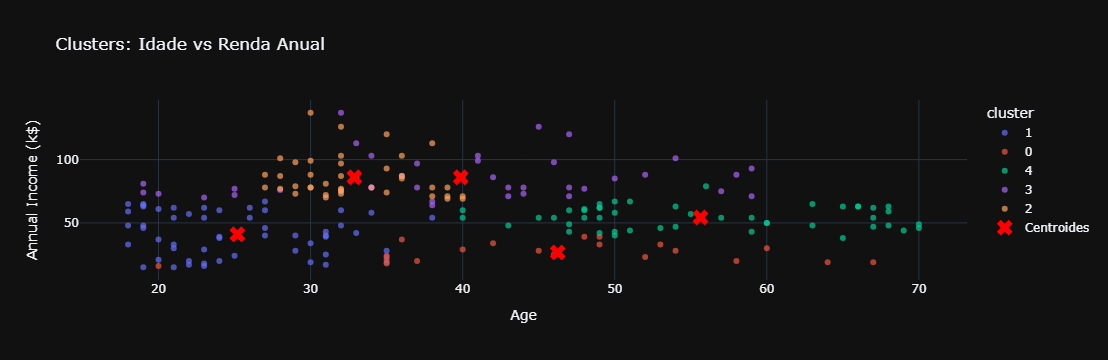

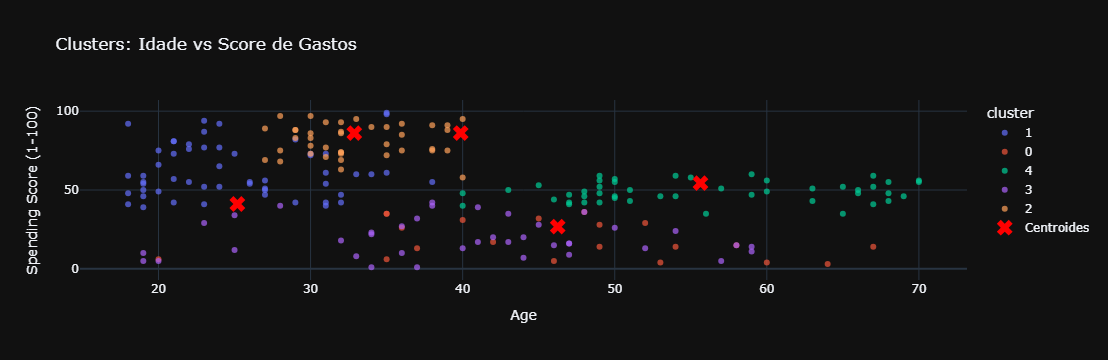

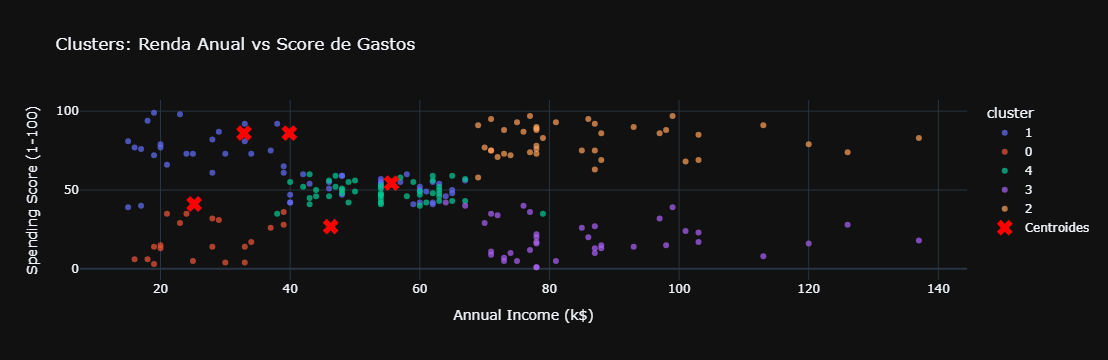

In [18]:
# Criar DataFrame com colunas padronizadas e rótulos de cluster
df_clusters = pd.DataFrame({
    'Age': base2['Age'],
    'Annual Income (k$)': base2['Annual Income (k$)'],
    'Spending Score (1-100)': base2['Spending Score (1-100)'],
    'cluster': labels.astype(str)
})

# Scatter plot Age vs Income
fig1 = px.scatter(df_clusters, x='Age', y='Annual Income (k$)', color='cluster',
                  opacity=0.7, template="plotly_dark",
                  title='Clusters: Idade vs Renda Anual')
fig1.add_scatter(x=centroides_ori[:,0], y=centroides_ori[:,1],
                 mode='markers', marker=dict(color='red', symbol='x', size=14),
                 name='Centroides')
fig1.show()

# Scatter plot Age vs Spending Score
fig2 = px.scatter(df_clusters, x='Age', y='Spending Score (1-100)', color='cluster',
                  opacity=0.7, template="plotly_dark",
                  title='Clusters: Idade vs Score de Gastos')
fig2.add_scatter(x=centroides_ori[:,0], y=centroides_ori[:,1],
                 mode='markers', marker=dict(color='red', symbol='x', size=14),
                 name='Centroides')
fig2.show()

# Scatter plot Income vs Spending Score
fig3 = px.scatter(df_clusters, x='Annual Income (k$)', y='Spending Score (1-100)', color='cluster',
                  opacity=0.7, template="plotly_dark",
                  title='Clusters: Renda Anual vs Score de Gastos')
fig3.add_scatter(x=centroides_ori[:,0], y=centroides_ori[:,1],
                 mode='markers', marker=dict(color='red', symbol='x', size=14),
                 name='Centroides')
fig3.show()

A partir desse resultado, temos:
- *Annual Income x Spending Score* apresentou clusters separados com diferentes perfisde clients
  - Alta renda e baixo gasto.
  - Alta renda e alto gasto.
  - Renda média e gasto médio.
  - Baixa renda e alto gasto.
  - Baixa renda e baixo gasto.
- *Age x Annual Income* apresentpu alguns clusters, mas não tão claros pois os clusters 0 e 3 se misturam e se distribuim de forma continua
- *Age x Spending Score* não apresentou clusters fortes, com grandes dispersões em todas as faixas etárias.


Desta forma, será refeito o Kmeans, sem considerar a idade como fator

In [19]:
base3 = base2.drop(columns=['Age'])

base_std_3 = base3.copy()

colunas_std_3 = ['Annual Income (k$)', 'Spending Score (1-100)']

# Inicializar o StandardScaler
scaler = StandardScaler()

# Ajustar e transformar os dados selecionados
base_std_3[colunas_std_3] = scaler.fit_transform(base3[colunas_std_3])

In [20]:
base_std_3

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980
...,...,...
195,2.268791,1.118061
196,2.497807,-0.861839
197,2.497807,0.923953
198,2.917671,-1.250054


In [21]:
#Aplicar K-means
kmeans_mall_3 = KMeans (n_clusters=5, n_init=10, random_state=42)
kmeans_mall_3.fit(base_std_3)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [22]:
centroides_3 = kmeans_mall_3.cluster_centers_
centroides_3

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

In [23]:
centroides_std_3 = kmeans_mall_3.cluster_centers_

# Inverter a padronização para obter os centroides originais
centroides_ori_3 = scaler.inverse_transform(centroides_std_3)
centroides_ori_3

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

In [24]:
labels_3 = kmeans_mall_3.labels_
labels_3

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [25]:
df_clusters3 = pd.DataFrame({
    'Annual Income (k$)': base3['Annual Income (k$)'],
    'Spending Score (1-100)': base3['Spending Score (1-100)'],
    'cluster': labels_3.astype(str)
})

fig3 = px.scatter(df_clusters3, x='Annual Income (k$)', y='Spending Score (1-100)', color='cluster',
                  opacity=0.7, template="plotly_dark",
                  title='Clusters: Renda Anual vs Score de Gastos')
fig3.add_scatter(x=centroides_ori_3[:,0], y=centroides_ori_3[:,1],
                 mode='markers', marker=dict(color='red', symbol='x', size=14),
                 name='Centroides')
fig3.show()

Ao remover a variavel **Age**, os clusters ficaram mais definidos

# Insights  
Perfis identificáveis:

 - Alta renda / baixo gasto -> clientes com potencial, mas que não gastam muito.

 - Alta renda / alto gasto -> clientes premium, provavelmente os mais valiosos.

 - Baixa renda / alto gasto -> clientes que gastam proporcionalmente muito, podem ser fiéis ou impulsivos.

 - Baixa renda / baixo gasto -> clientes de baixo valor, menos estratégicos.

 - Renda média / gasto médio -> grupo intermediário, pode ser trabalhado para aumentar valor.

# Aplicações práticas por cluster

 - Alta renda / alto gasto (**clientes premium**):
   - Estratégia: programas de fidelidade exclusivos, acesso antecipado a lançamentos, experiências VIP.
   - Objetivo: manter engajamento e aumentar retenção.
 - Alta renda / baixo gasto (**clientes potenciais**)
   - Estratégia: campanhas de incentivo ao consumo, ofertas personalizadas de produtos de maior valor agregado.
   - Objetivo: estimular aumento de ticket médio/Spending score.  
- Renda média / gasto médio (**clientes regulares**)
   - Estratégia: promoções sazonais, pacotes combinados, descontos progressivos.
   - Objetivo: consolidar relacionamento e evitar churn.  
- Baixa renda / alto gasto (**clientes fiéis ou impulsivos**)
   - Estratégia: programas de pontos, descontos em produtos populares, comunicação emocional.
   - Objetivo: reforçar fidelidade e maximizar recorrência.
 - Baixa renda / baixo gasto (**clientes de baixo valor**)
   - Estratégia: campanhas de baixo custo, ofertas básicas, comunicação automatizada.
   - Objetivo: reduzir esforço de marketing e manter apenas engajamento mínimo.

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

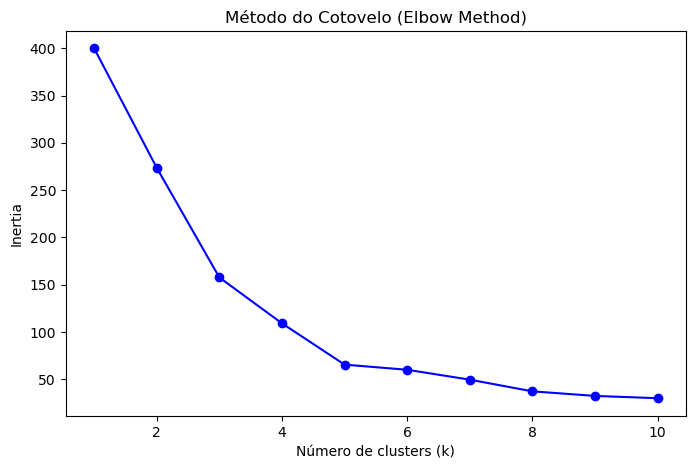

In [31]:
# Dados padronizados (ex.: base_std)
X = base_std_3[['Annual Income (k$)', 'Spending Score (1-100)']]

inertia = []
K = range(1, 11)  # testar de 1 a 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inertia')
plt.title('Método do Cotovelo (Elbow Method)')
plt.show()

In [28]:
from sklearn.metrics import silhouette_score

for k in range(4, 7):  # não faz sentido silhouette com k=1
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels_3 = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f'Clusters: {k}, Silhouette Score: {score:.3f}')

Clusters: 4, Silhouette Score: 0.296
Clusters: 5, Silhouette Score: 0.296
Clusters: 6, Silhouette Score: 0.296


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
